<a href="https://colab.research.google.com/github/sonyakuma-droid/EMSC2010-W2-P1/blob/main/eutrophication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Eutrophication: A Predictive Model for Gippsland Lakes (Victoria)**

**Introduction**

Eutrophication is the process where a waterbody becomes overly enriched with nutrients (primarily phosphorus and nitrogen) which fuel excessive algal growth leading to toxic algal blooms.

Chlorophyll-a is the specific green pigment found in plants, algae, and cyanobacteria that is essential for photosynthesis and oxygen production in marine and freshwater. Chlorophyll-a is used as a proxy for eutrophication because it directly measures algal biomass resulting from nutrient enrichment.

One of the indicators of water quality condition is the increase of algae and cyanobacteria (or blue-green algae) biomass as measured by the concentration of chlorophyll-a. Waters with high levels of nutrients such as nitrogen or phoshorus from fertilizers, septic systems, sewage treatment plants and urban runoff may have high concentrations of chlorophyll-a and excess amounts of algae and cyanobacteria. Hence,  chlorophyll-a measured in the water column is used to classify the trophic condition of a waterbody (oligotrophic, mesotrophic, eutrophic or hypereutrophic) into good, fair or poor biological condition.

Excessive algal growth is a major ecological challenge in
freshwater lakes which negatively affects oxygen levels and ecosystem functions. Human activities have contributed to increased nutrient pollution, directly affecting algal biomass and increasing the risk of eutrophication. Eutrophication is directly linked to the growth of toxic algae, which can threaten human health and endanger aquatic life. Therefore, the effective control of algal biomass is essential and requires accurate prediction.

**Aim**

The study aims to determine the predictive value of 6 key water quality parameters: namely, total nitrogen (N_TOTAL),total phosphorus P_TOTAL), water temperature, pH, dissolved oxygen (DO), and turbidity.
Known to be key drivers of eutrophication, nitrogen and phosphorus are expected to be dominant contributors. Accordingly, it asks the following research question: Does this provide an effective model  for predicting and managing the risk of eutrophication?


**Materials and methods**

This study uses EPA Victoria Gippsland Lakes Water Quality Data 1990-2025 collected from seven fixed sites: Lake Wellington, Lake Victoria, Lake King South, Lake King North, Shaving Point, Lake Reeve East and West. It contains water sample data on a range of 20 nutrient and physical parameters pertaining to water quality including  chlorophyll-a, nitrogen, phosphous, pH, silica and water temperature. Data is collected monthly, where possible, at surface and bottom locations.

Chlorophyll-a, which acts as a proxy for eutrophication, is the dependent variable. The independent variables are total nitrogen, total phosphorus, dissolved oxygen, pH, dissolved oxygen, and turbidity.

Selected variables were tested for skewness, showing surface and bottom values. Null values were replaced with mean values, where necessary, for each of the variables to enable correlations to be performed. In addition, the number of values representing each of the variables was matched. Results were visualised in a Spearman Correlation Heatmap.

Finally, a multiple linear regression was performed to determine the effectiveness of the model.





**Results and analysis**

In [ ]:
import numpy as np # NumPy for numerical computing
import matplotlib.pyplot as plt #plotting library
import pandas as pd #Pandas for data handling
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm


In [ ]:
#reading in data file and creating dataframe
file = '/1990_01-2025_06_Gippsland_Lakes_Water_quality_data.xlsx' #read in data excel file
df = pd.read_excel(file, sheet_name='Data') #read file and 'Data' into df
#df.head() #show the header information
df.info()
df.isnull().sum()
df.site_name_short.unique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3445 entries, 0 to 3444
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   site_id          3445 non-null   int64         
 1   site_name_short  3445 non-null   object        
 2   water_body       3445 non-null   object        
 3   date             3445 non-null   datetime64[ns]
 4   Type             3445 non-null   object        
 5   CHL_A            2247 non-null   float64       
 6   Secchi_depth_m   1595 non-null   float64       
 7   DO_mg            2953 non-null   float64       
 8   FL               1138 non-null   float64       
 9   PAR              1473 non-null   float64       
 10  Sal              3170 non-null   float64       
 11  Temp             2826 non-null   float64       
 12  Turb             1144 non-null   float64       
 13  DO_sat           2461 non-null   float64       
 14  Temperature      4 non-null      float64

array(['Lake Wellington', 'Lake Victoria', 'Lake King South',
       'Lake King North', 'Shaving Point', 'Lake Reeve\xa0East',
       'Lake Reeve\xa0West'], dtype=object)

In [ ]:
#creating dataframe with values of interest
df_io_para = df[['site_name_short', 'date', 'Type','CHL_A','DO_mg','Temp','Sal','N_NH3','N_NO2','N_NO3','N_NOX','N_TOTAL','P_TOTAL','TSS','Turb','pH','SI']].copy()
df_io_para_bot = df_io_para.query('Type == "bottom"').copy()
df_io_para_top = df_io_para.query('Type == "surface"').copy()
df_sns = df[['Temp','CHL_A','DO_mg','N_NH3','N_NO2','N_NO3','N_TOTAL','P_TOTAL','Turb','pH','SI']].copy()
X = df_io_para[['P_TOTAL','N_TOTAL','Temp','pH','DO_mg','Turb']].copy()
y = df_io_para[['CHL_A']].copy()
print(' X   ',X.shape,'     y   ',y.shape)
# all null values were replaced by their mean value to enable correlations to be performed
X[['P_TOTAL','N_TOTAL','Temp','pH','DO_mg','Turb']] = X[['P_TOTAL','N_TOTAL','Temp','pH','DO_mg','Turb']].fillna(X[['P_TOTAL','N_TOTAL','Temp','pH','DO_mg','Turb']].mean())
y[['CHL_A']] = y[['CHL_A']].fillna(y[['CHL_A']].mean())
print(' X   ',X.shape,'     y   ',y.shape)
print(X.head(20))
print(' ---------------------------')
print(df_io_para.groupby(['Type'])[['P_TOTAL','N_TOTAL','Temp','pH','DO_mg','Turb']].agg(['min','mean','max']))
print('----------------------------')
print(y.head(20))

#print(df_io_para_bot.head(10))
print(df_io_para_bot.shape)
df_io_para_bot = df_io_para_bot.dropna() #remove rows with NaN missing values
n_nh3_bot = df_io_para_bot['N_NH3'].to_numpy() #convert N_NH3 into numpy array
n_no2_bot = df_io_para_bot['N_NO2'].to_numpy() #convert N_NO2 into numpy array
n_total_bot = df_io_para_bot['N_TOTAL'].to_numpy() #convert N_TOTALinto numpy array
n_ph_bot = df_io_para_bot['pH'].to_numpy() #convert pH into numpy array
n_temp_bot = df_io_para_bot['Temp'].to_numpy() #convert Temp into numpy array
n_turb_bot = df_io_para_bot['Turb'].to_numpy() #convert Turb into numpy array

df_io_para_top = df_io_para_top.dropna() #remove rows with NaN missing values
n_nh3_top = df_io_para_top['N_NH3'].to_numpy() #convert N_NH3 into numpy array
n_no2_top = df_io_para_top['N_NO2'].to_numpy() #convert N_NO2 into numpy array
n_total_top = df_io_para_top['N_TOTAL'].to_numpy() #convert pH N_TOTAL into numpy array
n_turb_top = df_io_para_top['Turb'].to_numpy() #convert Turb into numpy array
n_ph_top = df_io_para_top['pH'].to_numpy() #convert pH into numpy array
n_temp_top = df_io_para_top['Temp'].to_numpy() #convert Temp into numpy array



#df_io_para.head(20) #show the header information
#df_io_para.Type.value_counts()
#print('--------------------------')
#print(df.shape)

 X    (3445, 6)      y    (3445, 1)
 X    (3445, 6)      y    (3445, 1)
    P_TOTAL  N_TOTAL  Temp        pH     DO_mg      Turb
0     32.52   574.23  22.1  7.900000  8.209804  5.912904
1     34.48   580.81  20.4  7.800000  8.209804  5.912904
2     41.56   526.85  21.5  8.076151  8.209804  5.912904
3    107.53   456.93  20.4  8.076151  8.209804  5.912904
4     47.69   831.75  22.2  8.076151  8.209804  5.912904
5     42.90   376.69  19.4  8.076151  8.209804  5.912904
6     24.09   569.84  21.9  8.076151  8.209804  5.912904
7     99.51   609.15  20.0  8.076151  8.209804  5.912904
8     30.36   707.10  21.5  8.076151  8.209804  5.912904
9     10.89   264.88  19.4  8.076151  8.209804  5.912904
10    62.63   573.78  18.4  7.900000  8.209804  5.912904
11    72.66   640.77  18.4  8.200000  8.209804  5.912904
12    84.14   643.78  19.4  8.400000  8.209804  5.912904
13   322.45  1375.60  19.6  7.800000  8.209804  5.912904
14    56.61   563.64  19.8  8.300000  8.209804  5.912904
15    51.18   34

In [ ]:
#creating dataframe with values of interest
df_io_para = df[['site_name_short', 'date', 'Type','CHL_A','DO_mg','Temp','Sal','N_NH3','N_NO2','N_NO3','N_NOX','N_TOTAL','P_TOTAL','TSS','Turb','pH','SI']].copy()
df_io_para_bot = df_io_para.query('Type == "bottom"').copy()
df_io_para_top = df_io_para.query('Type == "surface"').copy()
df_sns = df[['Temp','CHL_A','DO_mg','N_NH3','N_NO2','N_NO3','N_TOTAL','P_TOTAL','Turb','pH','SI']].copy()
X = df_io_para[['P_TOTAL','N_TOTAL','Temp','pH','DO_mg','Turb']].copy()
y = df_io_para[['CHL_A']].copy()
print(' X   ',X.shape,'     y   ',y.shape)
X[['P_TOTAL','N_TOTAL','Temp','pH','DO_mg','Turb']] = X[['P_TOTAL','N_TOTAL','Temp','pH','DO_mg','Turb']].fillna(X[['P_TOTAL','N_TOTAL','Temp','pH','DO_mg','Turb']].mean())
y[['CHL_A']] = y[['CHL_A']].fillna(y[['CHL_A']].mean())
print(' X   ',X.shape,'     y   ',y.shape)
print(X.head(20))
print(' ---------------------------')
print(df_io_para.groupby(['Type'])[['P_TOTAL','N_TOTAL','Temp','pH','DO_mg','Turb']].agg(['min','mean','max']))
print('----------------------------')
print(y.head(20))

#print(df_io_para_bot.head(10))
print(df_io_para_bot.shape)
df_io_para_bot = df_io_para_bot.dropna() #remove rows with NaN missing values
n_nh3_bot = df_io_para_bot['N_NH3'].to_numpy() #convert N_NH3 into numpy array
n_no2_bot = df_io_para_bot['N_NO2'].to_numpy() #convert N_NO2 into numpy array
n_total_bot = df_io_para_bot['N_TOTAL'].to_numpy() #convert N_TOTALinto numpy array
n_ph_bot = df_io_para_bot['pH'].to_numpy() #convert pH into numpy array
n_temp_bot = df_io_para_bot['Temp'].to_numpy() #convert Temp into numpy array
n_turb_bot = df_io_para_bot['Turb'].to_numpy() #convert Turb into numpy array

df_io_para_top = df_io_para_top.dropna() #remove rows with NaN missing values
n_nh3_top = df_io_para_top['N_NH3'].to_numpy() #convert N_NH3 into numpy array
n_no2_top = df_io_para_top['N_NO2'].to_numpy() #convert N_NO2 into numpy array
n_total_top = df_io_para_top['N_TOTAL'].to_numpy() #convert pH N_TOTAL into numpy array
n_turb_top = df_io_para_top['Turb'].to_numpy() #convert Turb into numpy array
n_ph_top = df_io_para_top['pH'].to_numpy()
n_temp_top = df_io_para_top['Temp'].to_numpy()



#df_io_para.head(20) #show the header information
#df_io_para.Type.value_counts()
#print('--------------------------')
#print(df.shape)

 X    (3445, 6)      y    (3445, 1)
 X    (3445, 6)      y    (3445, 1)
    P_TOTAL  N_TOTAL  Temp        pH     DO_mg      Turb
0     32.52   574.23  22.1  7.900000  8.209804  5.912904
1     34.48   580.81  20.4  7.800000  8.209804  5.912904
2     41.56   526.85  21.5  8.076151  8.209804  5.912904
3    107.53   456.93  20.4  8.076151  8.209804  5.912904
4     47.69   831.75  22.2  8.076151  8.209804  5.912904
5     42.90   376.69  19.4  8.076151  8.209804  5.912904
6     24.09   569.84  21.9  8.076151  8.209804  5.912904
7     99.51   609.15  20.0  8.076151  8.209804  5.912904
8     30.36   707.10  21.5  8.076151  8.209804  5.912904
9     10.89   264.88  19.4  8.076151  8.209804  5.912904
10    62.63   573.78  18.4  7.900000  8.209804  5.912904
11    72.66   640.77  18.4  8.200000  8.209804  5.912904
12    84.14   643.78  19.4  8.400000  8.209804  5.912904
13   322.45  1375.60  19.6  7.800000  8.209804  5.912904
14    56.61   563.64  19.8  8.300000  8.209804  5.912904
15    51.18   34

In [ ]:
#creating dataframe with values of interest
df_io_para = df[['site_name_short', 'date', 'Type','CHL_A','DO_mg','Temp','Sal','N_NH3','N_NO2','N_NO3','N_NOX','N_TOTAL','P_TOTAL','TSS','Turb','pH','SI']].copy()
df_io_para_bot = df_io_para.query('Type == "bottom"').copy()
df_io_para_top = df_io_para.query('Type == "surface"').copy()
df_sns = df[['Temp','CHL_A','DO_mg','N_NH3','N_NO2','N_NO3','N_TOTAL','P_TOTAL','Turb','pH','SI']].copy()
X = df_io_para[['P_TOTAL','N_TOTAL','Temp','pH','DO_mg','Turb']].copy()
y = df_io_para[['CHL_A']].copy()
print(' X   ',X.shape,'     y   ',y.shape)
X[['P_TOTAL','N_TOTAL','Temp','pH','DO_mg','Turb']] = X[['P_TOTAL','N_TOTAL','Temp','pH','DO_mg','Turb']].fillna(X[['P_TOTAL','N_TOTAL','Temp','pH','DO_mg','Turb']].mean())
y[['CHL_A']] = y[['CHL_A']].fillna(y[['CHL_A']].mean())
print(' X   ',X.shape,'     y   ',y.shape)
print(X.head(20))
print(' ---------------------------')
print(y.head(20))

#print(df_io_para_bot.head(10))
print(df_io_para_bot.shape)
df_io_para_bot = df_io_para_bot.dropna() #remove rows with NaN missing values
n_nh3_bot = df_io_para_bot['N_NH3'].to_numpy() #convert N_NH3 into numpy array
n_no2_bot = df_io_para_bot['N_NO2'].to_numpy() #convert N_NO2 into numpy array
n_total_bot = df_io_para_bot['N_TOTAL'].to_numpy() #convert N_TOTALinto numpy array
n_ph_bot = df_io_para_bot['pH'].to_numpy() #convert pH into numpy array
n_temp_bot = df_io_para_bot['Temp'].to_numpy() #convert Temp into numpy array
n_turb_bot = df_io_para_bot['Turb'].to_numpy() #convert Turb into numpy array

df_io_para_top = df_io_para_top.dropna() #remove rows with NaN missing values
n_nh3_top = df_io_para_top['N_NH3'].to_numpy() #convert N_NH3 into numpy array
n_no2_top = df_io_para_top['N_NO2'].to_numpy() #convert N_NO2 into numpy array
n_total_top = df_io_para_top['N_TOTAL'].to_numpy() #convert pH N_TOTAL into numpy array
n_turb_top = df_io_para_top['Turb'].to_numpy() #convert Turb into numpy array
n_ph_top = df_io_para_top['pH'].to_numpy()
n_temp_top = df_io_para_top['Temp'].to_numpy()

n_turb_bot_log = np.log(df_io_para_bot['Turb']).to_numpy() #convert Turb into numpy array
n_turb_top_log = np.log(df_io_para_top['Turb']).to_numpy() #convert Turb into numpy array


#df_io_para.head(20) #show the header information
#df_io_para.Type.value_counts()
#print('--------------------------')
#print(df.shape)

 X    (3445, 6)      y    (3445, 1)
 X    (3445, 6)      y    (3445, 1)
    P_TOTAL  N_TOTAL  Temp        pH     DO_mg      Turb
0     32.52   574.23  22.1  7.900000  8.209804  5.912904
1     34.48   580.81  20.4  7.800000  8.209804  5.912904
2     41.56   526.85  21.5  8.076151  8.209804  5.912904
3    107.53   456.93  20.4  8.076151  8.209804  5.912904
4     47.69   831.75  22.2  8.076151  8.209804  5.912904
5     42.90   376.69  19.4  8.076151  8.209804  5.912904
6     24.09   569.84  21.9  8.076151  8.209804  5.912904
7     99.51   609.15  20.0  8.076151  8.209804  5.912904
8     30.36   707.10  21.5  8.076151  8.209804  5.912904
9     10.89   264.88  19.4  8.076151  8.209804  5.912904
10    62.63   573.78  18.4  7.900000  8.209804  5.912904
11    72.66   640.77  18.4  8.200000  8.209804  5.912904
12    84.14   643.78  19.4  8.400000  8.209804  5.912904
13   322.45  1375.60  19.6  7.800000  8.209804  5.912904
14    56.61   563.64  19.8  8.300000  8.209804  5.912904
15    51.18   34

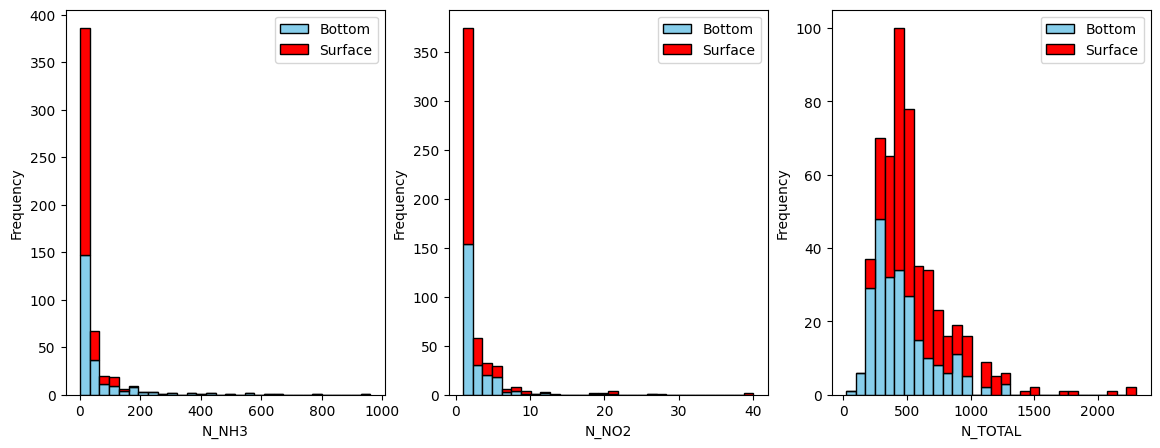

In [ ]:
# plotting data
fig, axes = plt.subplots(1,3, figsize=(14,5))

axes[0].hist([n_nh3_bot,n_nh3_top],bins=30, stacked=True,color = ['skyblue','red'], edgecolor='black') #Plot year and sst data
axes[0].set_xlabel('N_NH3')
axes[0].set_ylabel('Frequency')
axes[0].legend(['Bottom','Surface'],loc='upper right')
axes[1].hist([n_no2_bot,n_no2_top] ,bins=30, stacked=True, color = ['skyblue','red'], edgecolor='black') #Plot year and sst data
axes[1].set_xlabel('N_NO2')
axes[1].set_ylabel('Frequency')
axes[1].legend(['Bottom','Surface'],loc='upper right')
axes[2].hist([n_total_bot,n_total_top] ,bins=30, stacked=True, color = ['skyblue','red'], edgecolor='black') #Plot year and sst data
axes[2].set_xlabel('N_TOTAL')
axes[2].set_ylabel('Frequency')
axes[2].legend(['Bottom','Surface'],loc='upper right')
plt.tight_layout
plt.show()

Figure 1. Selected values of nitrogen showing skewness, surface and bottom measurements recorded.  

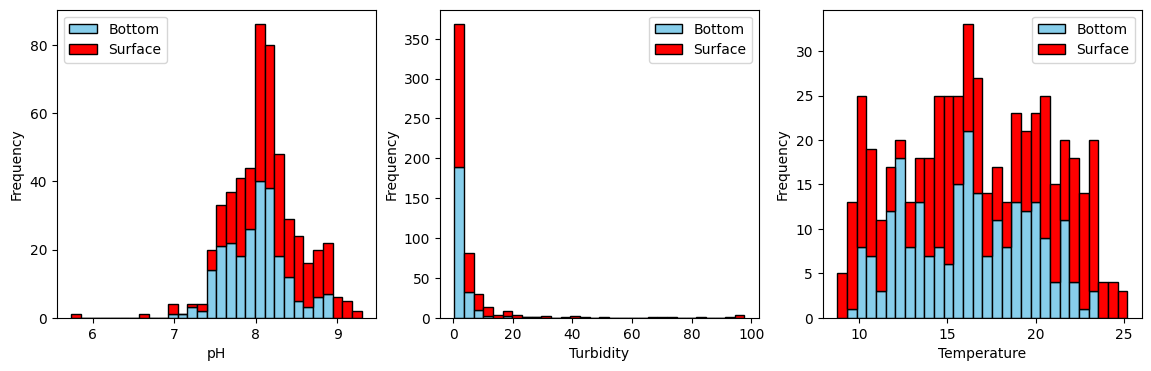

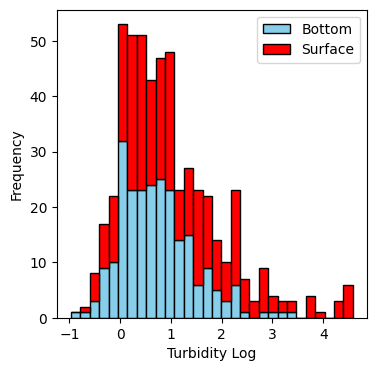

In [ ]:
#
fig, axes = plt.subplots(1,3, figsize=(14,4))

axes[0].hist([n_ph_bot,n_ph_top],bins=30,  stacked=True, color = ['skyblue','red'], edgecolor='black') #Plot year and sst data
axes[0].set_xlabel('pH')
axes[0].set_ylabel('Frequency')
axes[0].legend(['Bottom','Surface'],loc='upper left')
axes[1].hist([n_turb_bot,n_turb_top],bins=30,  stacked=True, color = ['skyblue','red'], edgecolor='black') #Plot year and sst data
axes[1].set_xlabel('Turbidity')
axes[1].set_ylabel('Frequency')
axes[1].legend(['Bottom','Surface'],loc='upper right')
axes[2].hist([n_temp_bot,n_temp_top],bins=30,  stacked=True, color = ['skyblue','red'], edgecolor='black') #Plot year and sst data
axes[2].set_xlabel('Temperature')
axes[2].set_ylabel('Frequency')
axes[2].legend(['Bottom','Surface'],loc='upper right')
plt.tight_layout
plt.show()

# log values
plt.figure(figsize=(4,4))
plt.hist([n_turb_bot_log,n_turb_top_log],bins=30,  stacked=True, color = ['skyblue','red'], edgecolor='black') #Plot year and sst data
plt.xlabel('Turbidity Log')
plt.ylabel('Frequency')
plt.legend(['Bottom','Surface'],loc='upper right')

plt.show()

Figure 2. Surface and bottom values for selected variables including log-transformed turbidity

Text(0.5, 1.0, 'Spearman Correlation Heatmap')

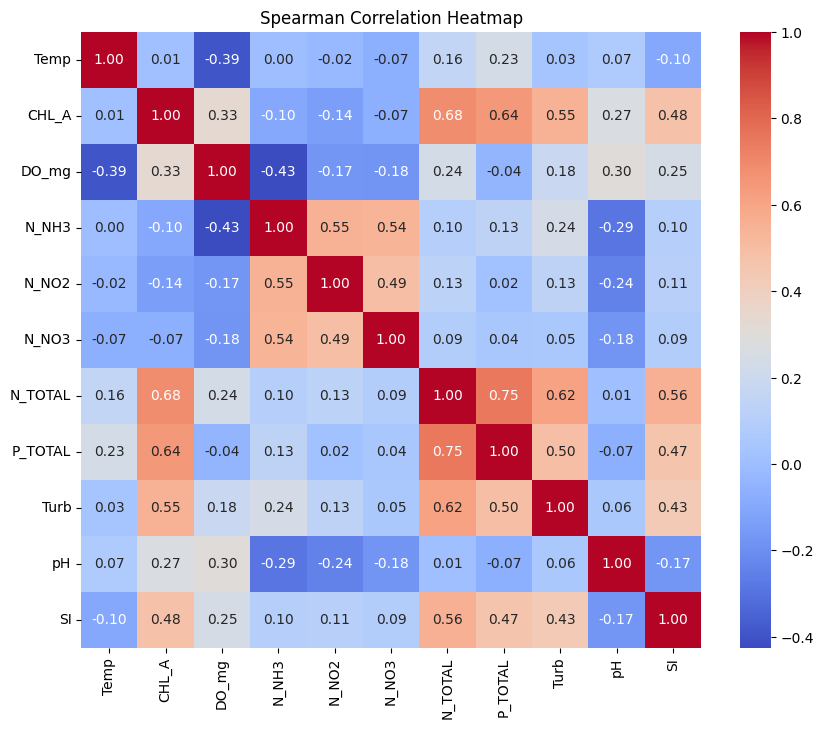

In [ ]:
corr_matrix = df_sns.corr(method='spearman')
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Spearman Correlation Heatmap')



Figure 3. A Spearman correlation heatmap is a color-coded visualization that displays the strength and direction of monotonic (non-linear) relationships between multiple pairs of variables at once. The chart usually includes a color bar ranging from -1.0 to
+1.0. Perfect Postive correlation, +1.0 (e.g. red): As one variable increases, the other variable strictly increases. Perfect Negative correlation, -1.0 (e.g. blue): As one variable increases, the other variable strictly decreases. 0 (e.g. grey): There is no consistent increasing or decreasing pattern.
While Pearson measures linear relationships, Spearman evaluates monotonic relationships by ranking the data rather than using the raw values.

Subjective strength (Moderate): 0.40 to 0.59.

Spearman rank correlation measures the strength and direction of the monotonic relationship between two variables. It evaluates how well the relationship can be described using a monotonically increasing or decreasing function, without requiring the data to be normally distributed or linear. In a linear relationship the rate of change is constant, whereas in a monotonic relationship the rate of change can vary but the general trend is in the same direction.


In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared:", r2_score(y_test, y_pred))



Mean Squared Error: 76.41742465754518
R-squared: 0.21797360316543835


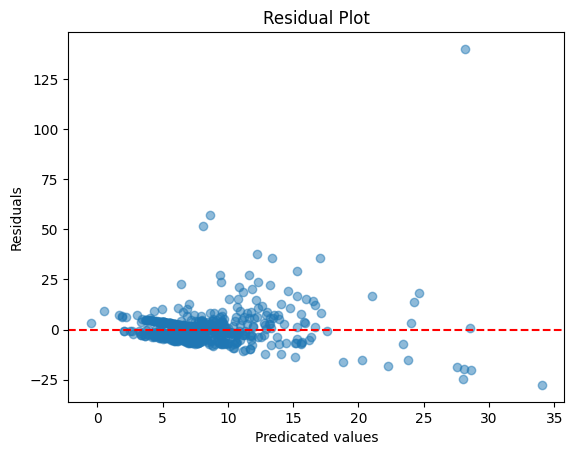

In [ ]:
residuals = y_test -y_pred
plt.scatter(y_pred, residuals, alpha=0.5)
plt.xlabel('Predicated values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

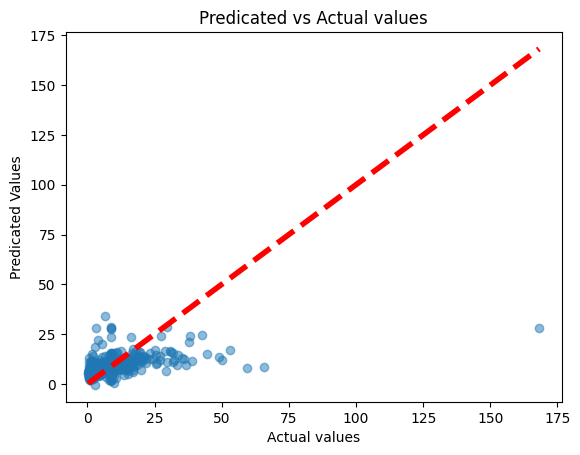

In [ ]:
#predicated vs Actual Plt
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual values')
plt.ylabel('Predicated Values')
plt.title('Predicated vs Actual values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--',lw=4)
plt.show()

In [ ]:
# Add a constant to the model
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())


                            OLS Regression Results                            
Dep. Variable:                  CHL_A   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     129.7
Date:                Thu, 28 May 2026   Prob (F-statistic):          6.82e-145
Time:                        05:03:26   Log-Likelihood:                -9587.7
No. Observations:                2756   AIC:                         1.919e+04
Df Residuals:                    2749   BIC:                         1.923e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.5989      0.150     57.453      0.0

Figure 4.

Note 1: x1 is total phosphorus; x2 is total nitrogen; x3 is water temperature; x4 is pH; x5 is dissolved oxygen; x6 is turbidity.

Note 2: Recall that turbidity refers to the "cloudiness" of a liquid caused by tiny suspended particles. When a liquid is turbid, these particles such as dirt, algae, or microscopic debris scatter and block light. This makes the water look opaque instead of clear.

Note 3: The model explains just 22 per cent of the variance in chlorophyll-a.

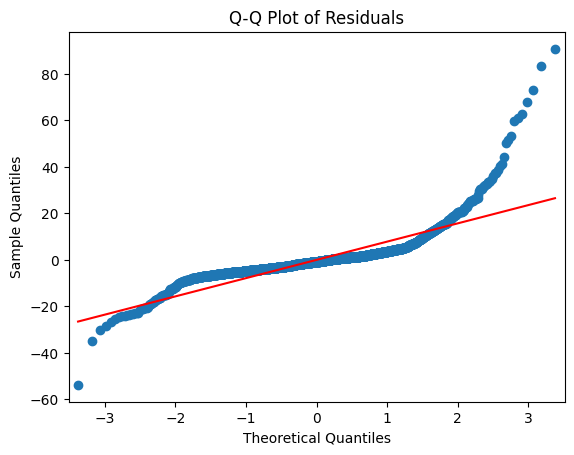

In [ ]:
# Q-Q Plot for residuals
sm.qqplot(model_sm.resid, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()

**Conclusion**

This is a relatively poor model for predicting the risk of eutrophication at Gippsland Lakes as it explains just 22 percent of the variance in chloropyll-a. Total phosphorus (2.40), total nitrogen (2.07), water temperature (-0.96) and pH (1.51) are the most influential independent variables.

Multiple Linear Regression assumes that a linear relationship exists between variables. The poor performance of this model suggests that the relationship between variables is non-linear. Hence, using a non-linear regression model would be more appropriate in this case.

**References**

Alderte, M. E., Rodriguez-Bangel, H., Jimenez, J. L. M., Sosa, L. A., Lepa, J. P., Rakun, J. R., Morales-Rosales, L. A. (2026). A data driven methodology for calculating key eutrophication parameters in water systems. *Water Quality Research Journal,*(0), 1-21. doi: 10.2166/wqrj.2026.065

EPA Victoria Gippsland Lakes Water Quality Data 1990-2025.
https://discover.data.vic.gov.au/dataset/gippsland-lakes-water-quality-data

Yun, Y-J., Jargal, N., & An, K-G. (2024). Developing practical models for predicting chlorophyll levels in the Andong Reservoir using empirical and machine learning approaches based on integrated analysis of physical, chemical, and hydrological indicators. *Ecological Indicators, 167*, 1-13. DOI:10.1016/j.ecolind.2024.112659
